In [59]:
import numpy as np
from matplotlib import pyplot as plt
import h5py
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from astroML.utils import completeness_contamination
import corner

In [2]:
# loading the data
data_full = h5py.File('../../solutions/sample_2e7_design_precessing_higherordermodes_3detectors(4).h5')
keys = list(data_full.keys())

In [3]:
# downsampling for debugging
ds = 1000 # take one every ds elements 
data = h5py.File("downsampled_data.h5", "w")

for k in keys:
    data.create_dataset(k, data=data_full[k][0::ds])

print(data['mtot'].shape)

(20000,)


In [4]:
keys

['chi1x',
 'chi1y',
 'chi1z',
 'chi2x',
 'chi2y',
 'chi2z',
 'dec',
 'det',
 'iota',
 'mtot',
 'psi',
 'q',
 'ra',
 'snr',
 'z']

In [42]:
# getting the data into scikit-learn format
feat_keys = ['mtot', 'q', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'ra', 'dec', 'iota', 'psi', 'z']    
X = np.vstack([data[k] for k in feat_keys]).T
snr = np.array(data['snr']) # signal to noise ratio
y = np.array(data['det']) #labels

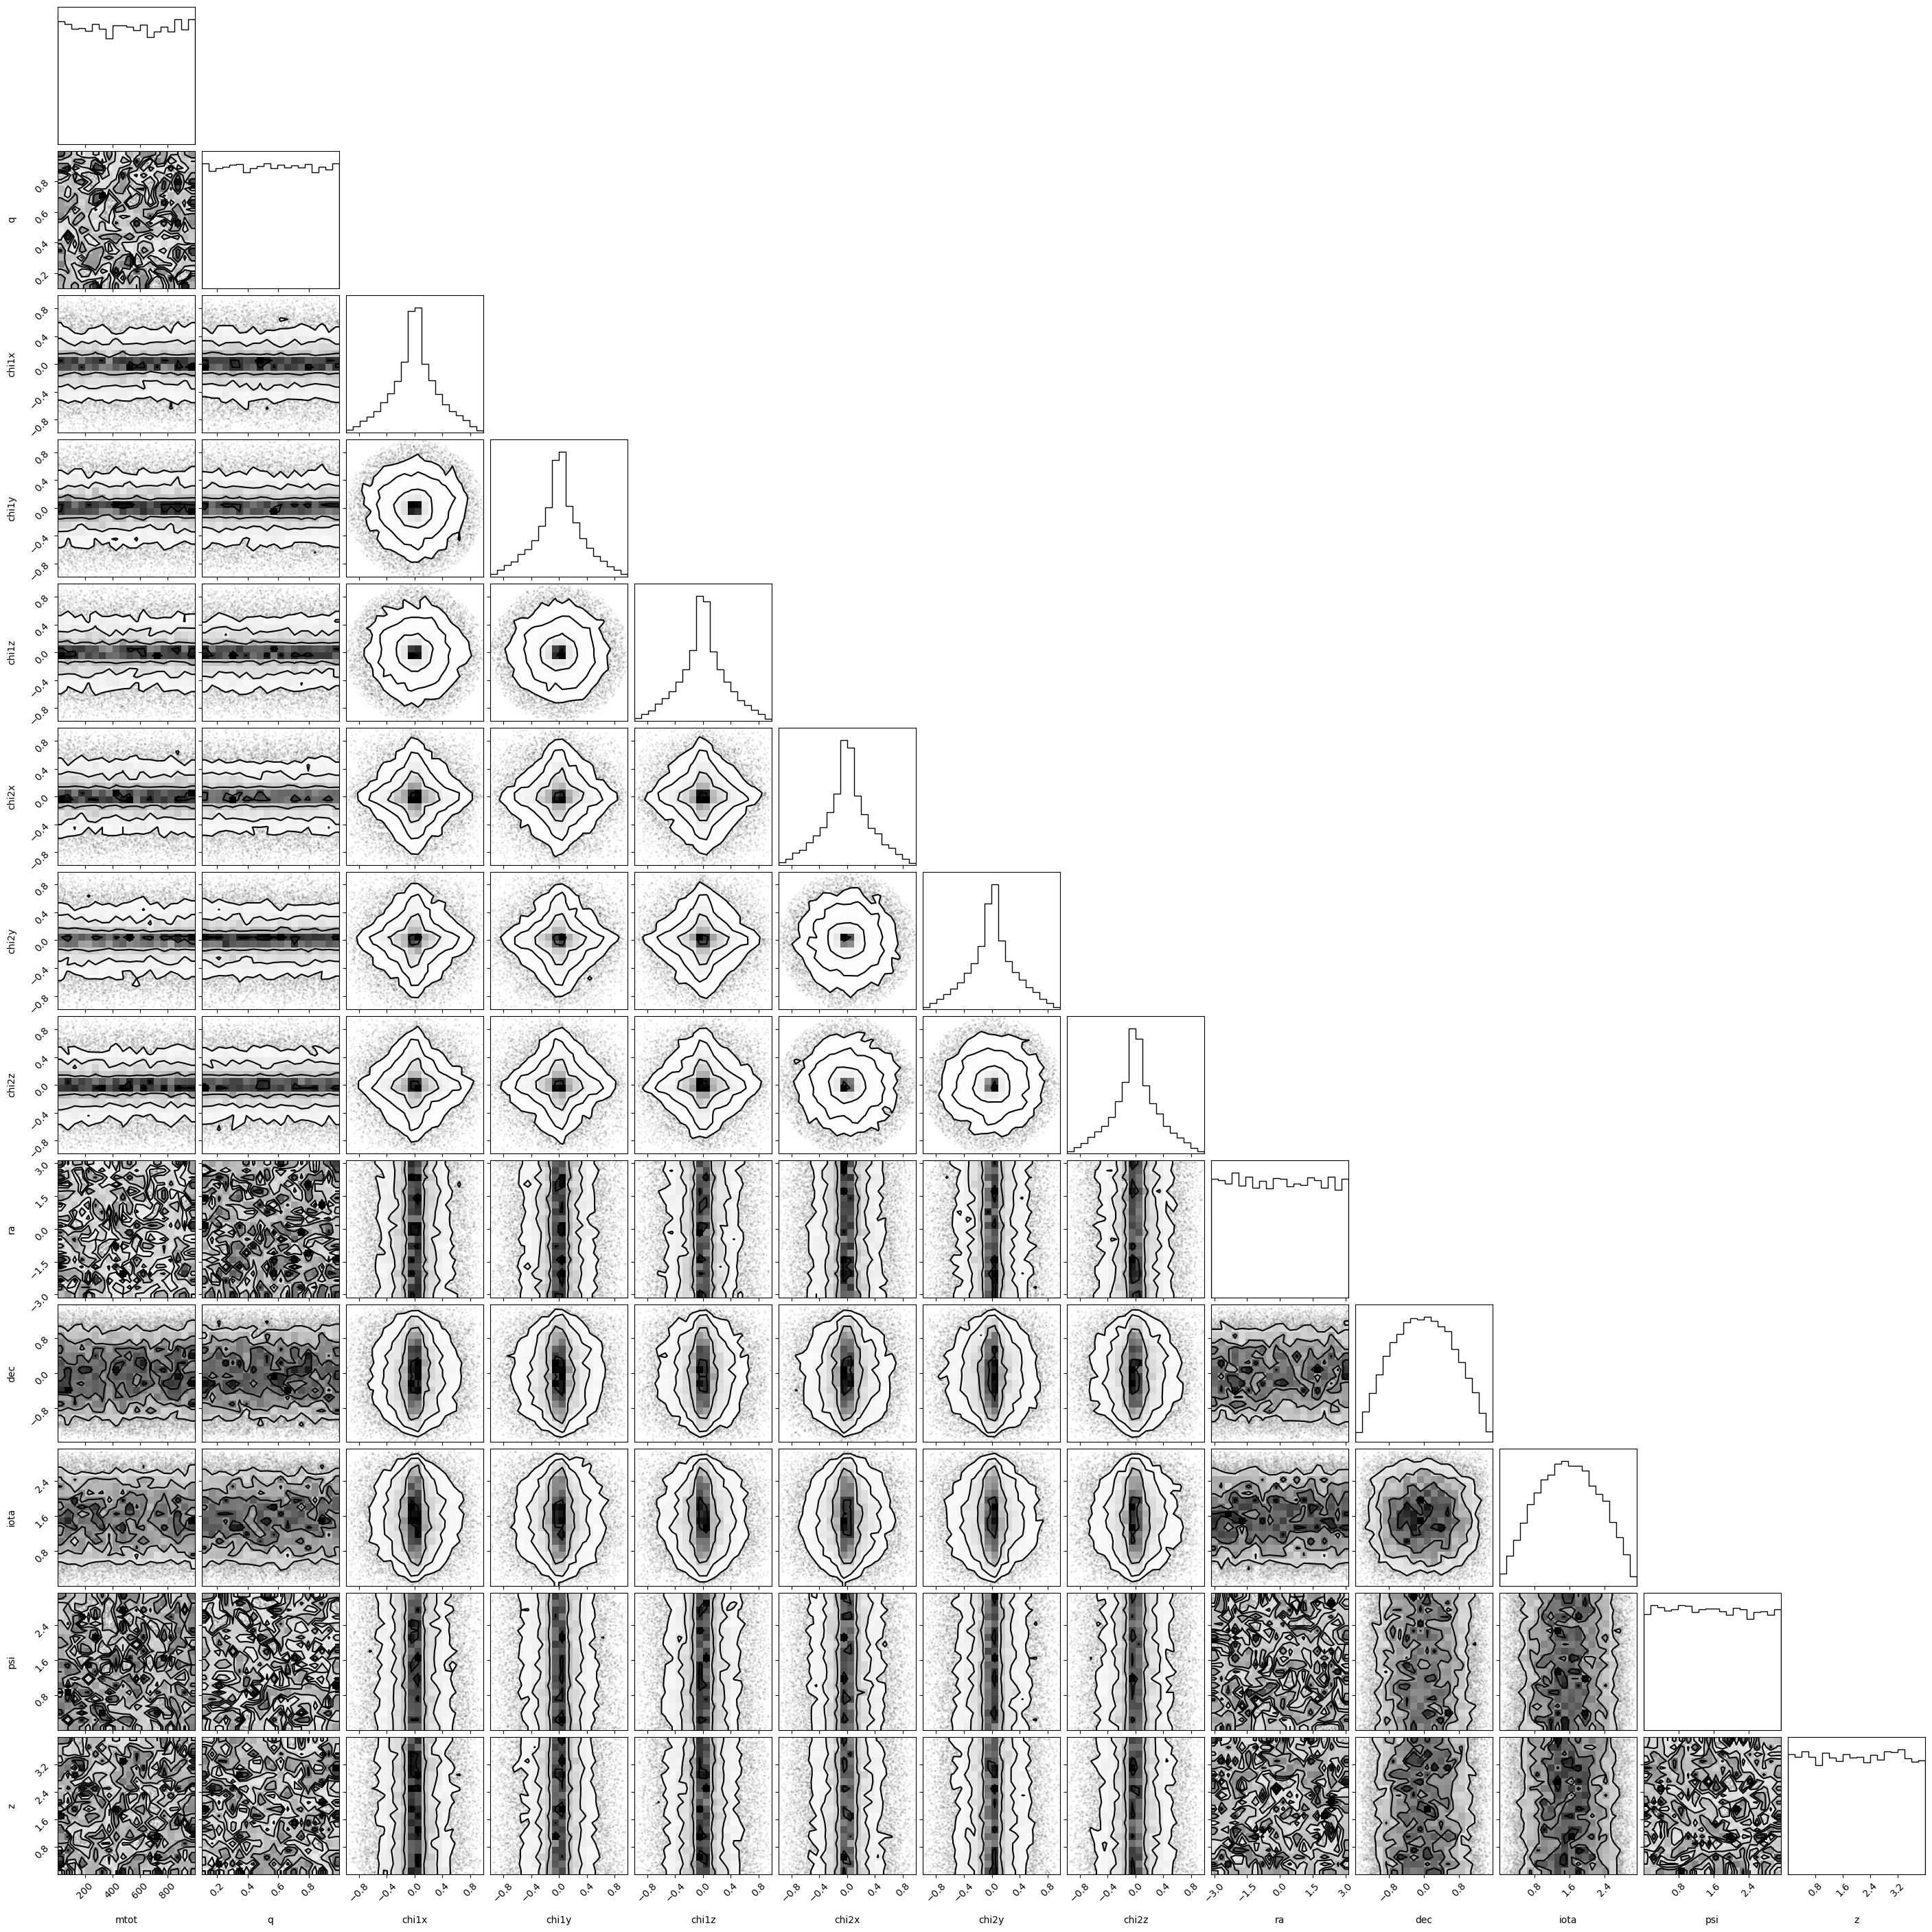

In [ ]:
#visualization of the feature distributions
fig = corner.corner(X, labels=feat_keys)

In [44]:
# splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

We compare different types of classification algorithms, cross validating the depth hyperparameter for each

## Decison Tree

In [45]:
#cross validating the max depth of the tree
k = 5 # number of folds
param_grid = {'max_depth': np.arange(1, 10)}
CV = GridSearchCV(DecisionTreeClassifier(), param_grid=param_grid, cv=k)

CV.fit(X_train, y_train)
d_best = CV.best_params_['max_depth']
print(d_best)

7


In [46]:
# estimator with tuned hyperparameter (max depth)
tree = DecisionTreeClassifier(max_depth=d_best)
tree.fit(X_train, y_train) # training the model

# predicting on the test set
prob = tree.predict_proba(X_test)
fpr_tree, tpr_tree, th_tree = roc_curve(y_test, prob[:, 1]) # ROC curve

## Bagging (decison tree)

In [35]:
# CV for max depth
estimator_grid = {'estimator': [DecisionTreeClassifier(max_depth=d) for d in np.arange(5, 16)]}
CV_bag = GridSearchCV(BaggingClassifier(bootstrap=True, n_estimators=100), param_grid=estimator_grid, cv =5)
CV_bag.fit(X_train, y_train)
print(CV_bag.best_params_['estimator'])

DecisionTreeClassifier(max_depth=np.int64(10))


In [47]:
d_best_bag = 10
bag_class = BaggingClassifier(
    DecisionTreeClassifier(random_state=35, max_depth=d_best_bag),
    n_estimators=100, bootstrap=True,
    n_jobs=-1, random_state=35
)
bag_class.fit(X_train, y_train)

# preidicting
bag_prob = bag_class.predict_proba(X_test)
fpr_bag, tpr_bag, th_bag = roc_curve(y_test, bag_prob[:, 1])

## Random Forest

In [48]:
# CV for max depth
param_grid = {'max_depth': np.arange(15, 25)}
CV_forest = GridSearchCV(RandomForestClassifier(n_estimators=100), param_grid=param_grid, cv=k)

CV_forest.fit(X_train, y_train)
d_best_for = CV_forest.best_params_['max_depth']
print(CV_forest.best_params_['max_depth'])


23


In [49]:
forest = RandomForestClassifier(n_estimators=100,
                                max_depth=d_best_for,
                                random_state=35)
forest.fit(X_train, y_train)

for_prob = forest.predict_proba(X_test)
fpr_for, tpr_for, th_for = roc_curve(y_test, for_prob[:, 1])

## Gradient Boosting

In [ ]:
param_grid = {'max_depth': np. arange(5, 15)}
CV_boost = GridSearchCV(GradientBoostingClassifier(n_estimators=100), param_grid=param_grid, cv=5)

CV_boost.fit(X_train, y_train)
d_best_boost = CV_boost.best_params_['max_depth']
print(d_best_boost)

6


In [50]:
d_best_boost=6
boost = GradientBoostingClassifier(max_depth=d_best_boost, n_estimators=100)
boost.fit(X_train, y_train)

boost_prob = boost.predict_proba(X_test)
fpr_boost, tpr_boost, th_boost = roc_curve(y_test, boost_prob[:, 1])

## ROC comparison

(0.0, 0.08)

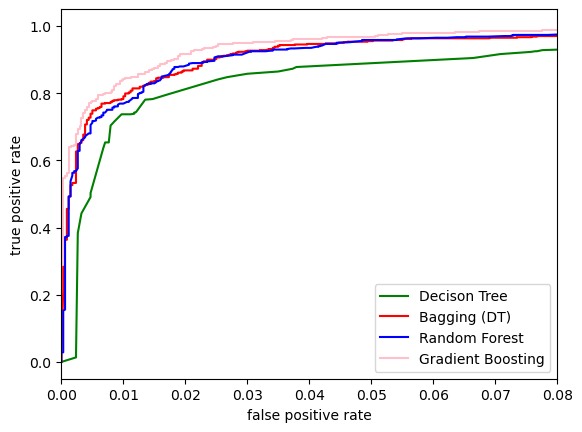

In [51]:
# comparing results for each of the considered classificators
plt.plot(fpr_tree, tpr_tree, c='g', label='Decison Tree')
plt.plot(fpr_bag, tpr_bag, c='r', label='Bagging (DT)')
plt.plot(fpr_for, tpr_for, c='blue', label='Random Forest')
plt.plot(fpr_boost, tpr_boost, c='pink', label='Gradient Boosting')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.legend()
plt.xlim(0., 0.08)


Gradient boosting classification yields the best results in terms of high completeness while also keeping a low false positive rate. Let's consider its completeness and efficiency as a function of the probability threshold

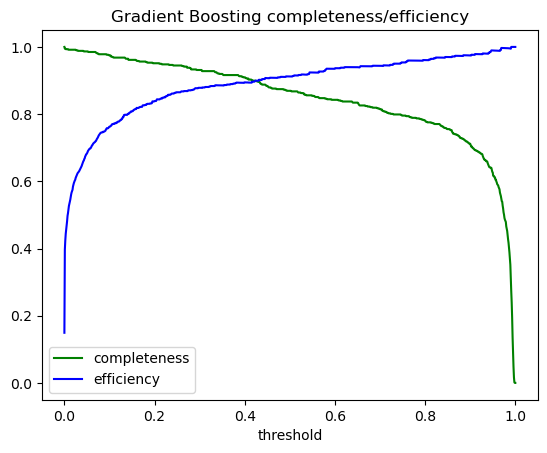

In [52]:
#getting completeness and efficiency as a function of the threshold t
thresholds = np.linspace(0., 1., 1000)

comp = []
eff = []

for t in thresholds:

    y_pred = (boost_prob[:, 1] >= t)

    comp_t, cont_t = completeness_contamination(y_pred, y_test)
    comp.append(comp_t)
    eff.append(1-cont_t) # efficiency =: 1 - contamination

#plott
plt.plot(thresholds, comp, c='green', label='completeness')
plt.plot(thresholds, eff, c='blue', label='efficiency')
plt.xlabel('threshold')
plt.title('Gradient Boosting completeness/efficiency')
plt.legend()



## Classification after dimensionality reduction

Let's see what happens if we try to claffify the data (with gradient boosting) after having reduced the dimensionality of the data with PCA (considering different number of components). 

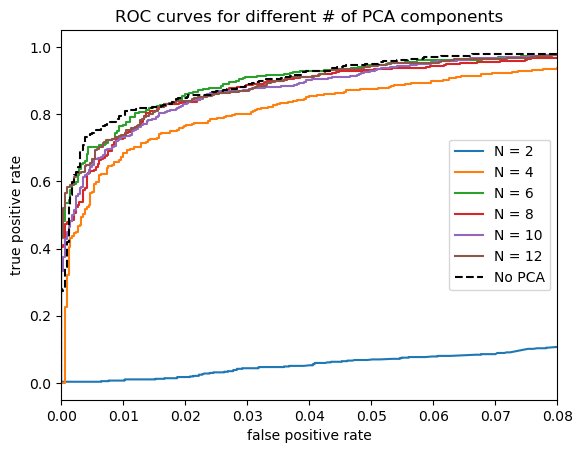

In [ ]:

for N in [2, 4, 6, 8, 10, 12]:  #number of dimensions considered

    pca = PCA(n_components=N)
    X_reduced = pca.fit_transform(X) #reducing the dimensionality
    X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, train_size=0.8)

    #classification
    d_best_npca=6
    boost = GradientBoostingClassifier(max_depth=d_best_npca, n_estimators=100)
    boost.fit(X_train, y_train)
    prob_npca = boost.predict_proba(X_test)
    fpr_npca, tpr_npca, th_npca = roc_curve(y_test, prob_npca[:, 1])

    plt.plot(fpr_npca, tpr_npca, label='N = %i'%N) #plotting the ROC curve

plt.plot(fpr_boost, tpr_boost, ls='dashed', c='black', label='No PCA') #best result without PCA
plt.xlim(0., 0.08)
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC curves for different # of PCA components')
plt.legend()
plt.show()

We see that with $N = 6$ PCA components we obtain similar or even better (for some values of the threshold) results than without dimensionality reduction, while cutting the data size in half. 

This makes applying PCA before classification a wise strategy to decrease computational cost without loosing completeness or efficiency.